# Load the Nsight data

Note: pipit does not ingest the raw .nsys-rep file format. You must pass pipit the
sqlite file generated from the nsys-rep file

In [1]:
import pipit

trace = pipit.Trace.from_nsight_sqlite("../llama3-8b-instruct-decode.sqlite")

/Users/thomasli/pipit/pipit/readers/nsight_sqlite_reader.py:223: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trace_df = pd.concat(traces, axis=0)


In [2]:
# View the events datafrmae
trace.events

,gpuId,Name,streamId,type,bytes,id,Process,meta,Trace Type,Event Type,Timestamp (ns),_matching_event,_matching_timestamp,_depth,_parent,_children,_kernel_launch
0,<NA>,cuProfilerStart,<NA>,<NA>,<NA>,10777,800101,None,cuda_api,Enter,9300489,1069,9311219,0.0,NaN,None,NaN
1069,<NA>,cuProfilerStart,<NA>,<NA>,<NA>,10777,800101,None,cuda_api,Leave,9311219,0,9300489,NaN,NaN,None,NaN
1,<NA>,cudaEventCreateWithFlags_v3020,<NA>,<NA>,<NA>,10781,800101,None,cuda_api,Enter,9413026,1070,9421583,0.0,NaN,None,NaN
1070,<NA>,cudaEventCreateWithFlags_v3020,<NA>,<NA>,<NA>,10781,800101,None,cuda_api,Leave,9421583,1,9413026,NaN,NaN,None,NaN
2,<NA>,cudaEventRecord_v3020,<NA>,<NA>,<NA>,10785,800101,None,cuda_api,Enter,9427254,1071,9441932,0.0,NaN,None,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2135,0,distribution_elementwise_grid_stride_kernel,7,kernel,<NA>,10888,800101,None,gpu_trace,Leave,39181779,1066,39178291,NaN,NaN,None,NaN
1067,0,triton_red_fused__softmax__to_copy_argmax_div_...,7,kernel,<NA>,10888,800101,None,gpu_trace,Enter,39181811,2136,39345427,0.0,20,None,NaN
2136,0,triton_red_fused__softmax__to_copy_argmax_div_...,7,kernel,<NA>,10888,800101,None,gpu_trace,Leave,39345427,1067,39181811,NaN,NaN,None,NaN
1068,0,triton_poi_fused_add_24,7,kernel,<NA>,10888,800101,None,gpu_trace,Enter,39345491,2137,39347699,0.0,20,None,NaN


In [3]:
# Generate a flat profile
# This is like the Nsight CUDA API/Kernel Summary except its all combined into on result series
breakdown = trace.flat_profile(
    parallelism_level=["Process", "gpuId"],
    mapper={"matmul": "ampere", "flash_attn": "flash"},
    ascending=False,
    idle_time=True
)
breakdown

,,,time.exc
Name,Process,gpuId,
matmul,800101,0,23744334
Other,800101,0,2551992
Idle Time,800101,0,1290826
flash_attn,800101,0,1160662


In [4]:
# Massage into format expected by pandas stacked bar chart plot
# (i.e. the names have to be in the columns, we use pivot to do this)
breakdown = breakdown.reset_index().pivot(columns="Name", values="time.exc", index=["Process", "gpuId"])
breakdown

,Name,Idle Time,Other,flash_attn,matmul
Process,gpuId,,,,
800101,0,1290826,2551992,1160662,23744334


Process  gpuId
800101   0        Axes(0.125,0.11;0.775x0.77)
dtype: object

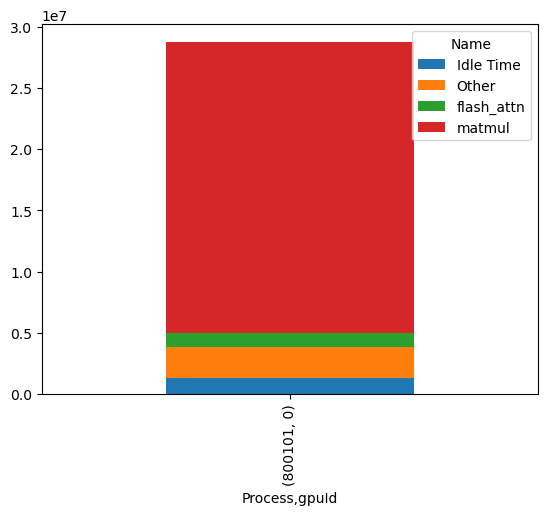

In [5]:
# Plot the profile
breakdown.groupby(["Process", "gpuId"]).plot.bar(stacked=True)

Process  gpuId
800101   0        Axes(0.125,0.11;0.775x0.77)
dtype: object

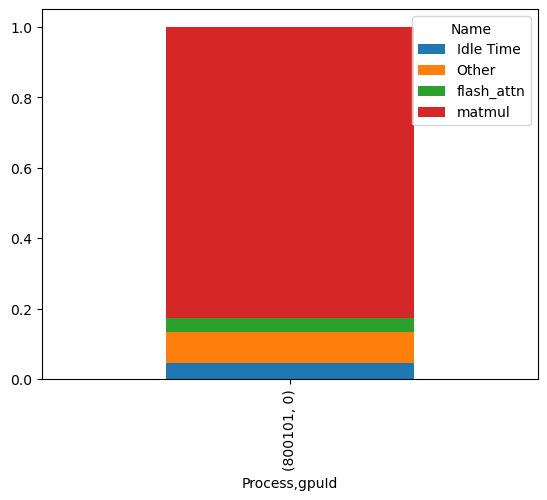

In [6]:
# Percentage breakdown
(breakdown / breakdown.sum(axis=1).squeeze()).groupby(["Process", "gpuId"]).plot.bar(stacked=True)